##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [1]:

import numpy as np
import tensorflow as tf
import keras
import keras_hub
import matplotlib.pyplot as plt
import urllib.request
from tensorflow.keras.utils import load_img, img_to_array

In [3]:
from google.colab import files
uploaded = files.upload()


Saving BANANA.webp to BANANA (1).webp
Saving CAT.webp to CAT (1).webp
Saving CLOCK.png to CLOCK (1).png
Saving HAMMER.png to HAMMER (1).png
Saving PARK_BENCH.jpg to PARK_BENCH.jpg


In [9]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"
urllib.request.urlretrieve(url, "imagenet_class_names.txt")

with open("imagenet_class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

if len(class_names) == 1001:
    class_names = class_names[1:]

print("Classes loaded:", len(class_names))

Classes loaded: 1000


In [5]:

preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)

print("ViT model loaded")

ViT model loaded


In [10]:
image_paths = [
    "PARK_BENCH.jpg",
    "HAMMER.png",
    "CLOCK.png",
    "BANANA.webp",
    "CAT.webp"
]

true_labels = [
    "park bench",
    "hammer",
    "clock",
    "banana",
    "cat"
]

images = []
display_images = []

for path in image_paths:
    img = load_img(path, color_mode="rgb")
    display_images.append(img)
    img_array = img_to_array(img).astype("uint8")
    images.append(img_array)

In [12]:
results = []

for i, img in enumerate(images):

    img_batch = tf.expand_dims(img, axis=0)

    preds = model.predict(img_batch, verbose=0)

    pred_index = np.argmax(preds[0])
    pred_label = class_names[pred_index]

    correct = "Yes" if (
        true_labels[i].lower() in pred_label.lower()
        or pred_label.lower() in true_labels[i].lower()
    ) else "No"

    results.append((image_paths[i], pred_label, true_labels[i], correct))

    print("Image File:", image_paths[i])
    print("Predicted Label:", pred_label)
    print("True Label:", true_labels[i])
    print("Correct?:", correct)
    print("-----------------------------")

Image File: PARK_BENCH.jpg
Predicted Label: park bench
True Label: park bench
Correct?: Yes
-----------------------------
Image File: HAMMER.png
Predicted Label: hammer
True Label: hammer
Correct?: Yes
-----------------------------
Image File: CLOCK.png
Predicted Label: analog clock
True Label: clock
Correct?: Yes
-----------------------------
Image File: BANANA.webp
Predicted Label: banana
True Label: banana
Correct?: Yes
-----------------------------
Image File: CAT.webp
Predicted Label: tiger cat
True Label: cat
Correct?: Yes
-----------------------------


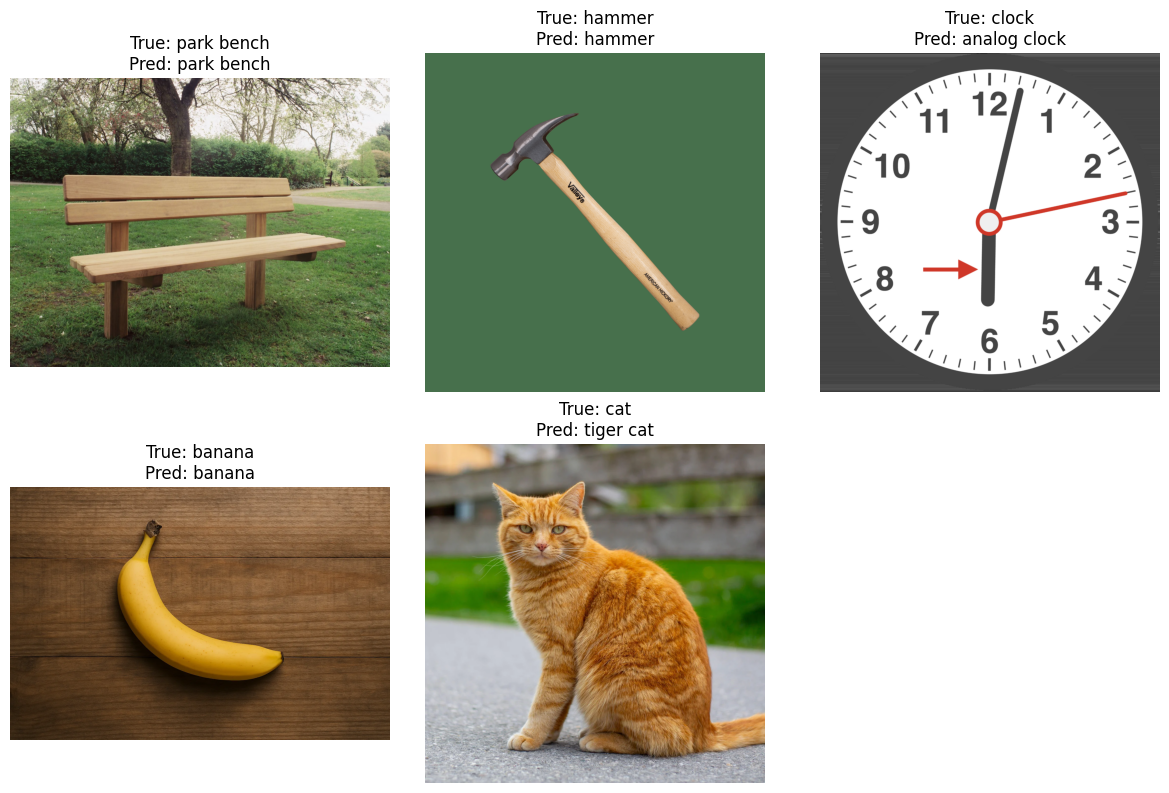

In [13]:
plt.figure(figsize=(12,8))

for i in range(len(display_images)):

    plt.subplot(2,3,i+1)
    plt.imshow(display_images[i])
    plt.title(f"True: {results[i][2]}\nPred: {results[i][1]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Record Your Results

Fill the table below based on your results:

| Image File      | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
|-----------------|-----------------|---------------------------------|-------------------|
| PARK_BENCH.jpg  | park bench      | park bench                      | Yes               |
| HAMMER.png      | hammer          | hammer                          | Yes               |
| CLOCK.png       | analog clock    | clock                           | Yes               |
| BANANA.webp     | banana          | banana                          | Yes               |
| CAT.webp        | tiger cat       | cat                             | Yes               |